# Credit Card Fraud Detection — Exploratory Data Analysis

Dataset: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) —
284,807 European card transactions from September 2013, of which 492 are
fraudulent. Features V1-V28 are PCA components of the original (undisclosed,
for confidentiality) transaction features; only `Time` and `Amount` are
untransformed.

This notebook explores the data before modeling. The actual training
pipeline (cleaning, feature engineering, SMOTE, model comparison) lives in
`src/train_pipeline.py` — this notebook is for understanding the data, not
for producing the final model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')
print(f"Shape: {df.shape}")
print(df.head().to_string())

Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361 -0.145783 -0.069083 -0.225775 -0.638672  0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.

## Class balance

This is the single most important thing to understand about this dataset before doing anything else.

In [2]:
class_counts = df['Class'].value_counts()
fraud_pct = class_counts[1] / len(df) * 100
print(f"Legitimate: {class_counts[0]:,}  ({100 - fraud_pct:.3f}%)")
print(f"Fraud:      {class_counts[1]:,}  ({fraud_pct:.3f}%)")
print(f"\nImbalance ratio: 1 fraud case per {class_counts[0] // class_counts[1]} legit transactions")

Legitimate: 284,315  (99.827%)
Fraud:      492  (0.173%)

Imbalance ratio: 1 fraud case per 577 legit transactions


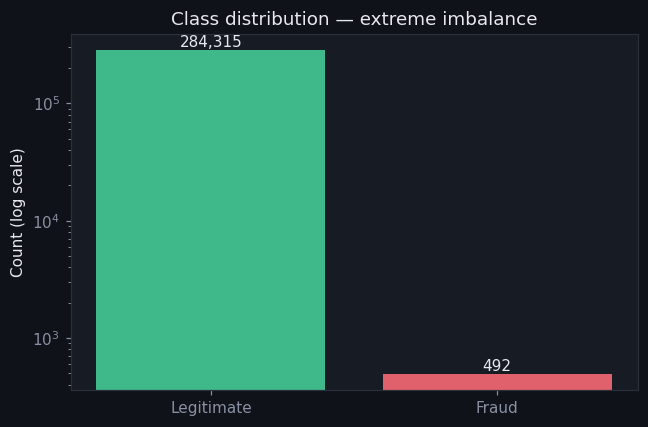

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Legitimate', 'Fraud'], [class_counts[0], class_counts[1]],
              color=['#3FB88A', '#E0616B'])
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title('Class distribution — extreme imbalance')
for bar, val in zip(bars, [class_counts[0], class_counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Takeaway:** with fraud at 0.17% of transactions, a model that always predicts "legitimate" would be 99.8% accurate while catching zero fraud. Accuracy is the wrong metric here — precision, recall, and PR-AUC on the fraud class matter far more (see `train_pipeline.py`).

## Duplicate transactions

In [4]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df):.2%} of the dataset)")
print("These get dropped before the train/test split in the pipeline, to avoid the same")
print("row appearing in both sets (data leakage).")

Duplicate rows: 1081 (0.38% of the dataset)
These get dropped before the train/test split in the pipeline, to avoid the same
row appearing in both sets (data leakage).


## Transaction amount

Median legit amount: $22.00
Median fraud amount: $9.25
Fraud transactions skew toward SMALLER amounts at the median — consistent with
fraudsters testing small transactions before attempting larger ones.


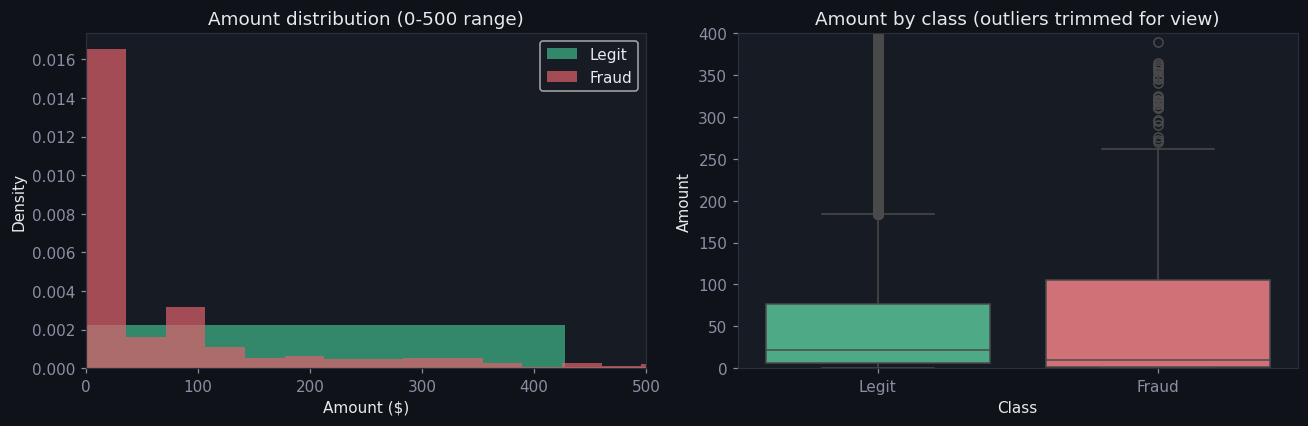

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df.Class==0]['Amount'], bins=60, color='#3FB88A', alpha=0.7, label='Legit', density=True)
axes[0].hist(df[df.Class==1]['Amount'], bins=60, color='#E0616B', alpha=0.7, label='Fraud', density=True)
axes[0].set_xlim(0, 500)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount distribution (0-500 range)')
axes[0].legend()

sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1], palette=['#3FB88A', '#E0616B'])
axes[1].set_ylim(0, 400)
axes[1].set_xticklabels(['Legit', 'Fraud'])
axes[1].set_title('Amount by class (outliers trimmed for view)')

plt.tight_layout()
plt.show()

print(f"Median legit amount: ${df[df.Class==0]['Amount'].median():.2f}")
print(f"Median fraud amount: ${df[df.Class==1]['Amount'].median():.2f}")
print("Fraud transactions skew toward SMALLER amounts at the median — consistent with")
print("fraudsters testing small transactions before attempting larger ones.")

## Fraud pattern by hour of day

`Time` is seconds elapsed since the first transaction (spans ~48 hours). Converting it to hour-of-day reveals whether fraud clusters at certain times.

Highest fraud rate: hour 2.0:00 (1.713%)
Late-night / early-morning hours show a noticeably higher fraud rate — likely
because overall transaction volume is lower then, so fraud makes up a larger share.


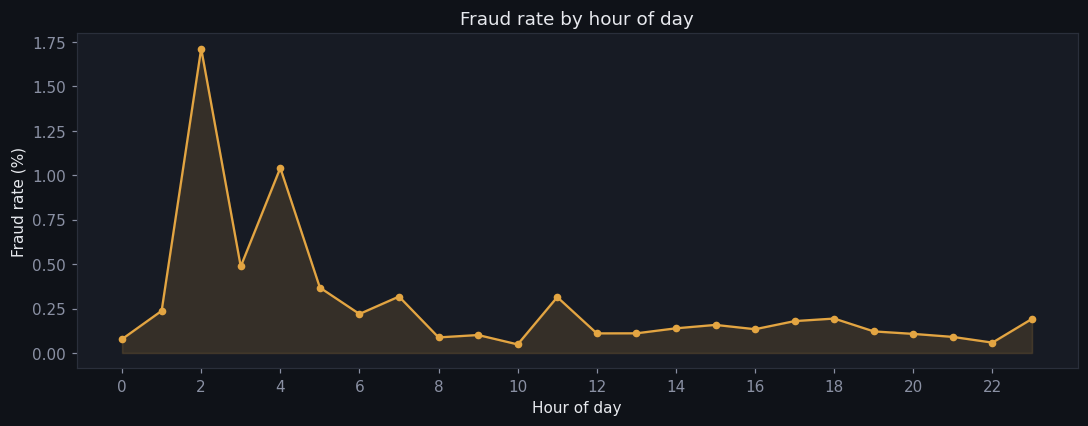

In [6]:
df['hour_of_day'] = (df['Time'] // 3600) % 24
hourly = df.groupby('hour_of_day')['Class'].agg(['count', 'sum'])
hourly['fraud_rate'] = hourly['sum'] / hourly['count'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly.index, hourly['fraud_rate'], color='#E3A542', marker='o', markersize=4)
ax.fill_between(hourly.index, hourly['fraud_rate'], color='#E3A542', alpha=0.15)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud rate by hour of day')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

peak_hour = hourly['fraud_rate'].idxmax()
print(f"Highest fraud rate: hour {peak_hour}:00 ({hourly['fraud_rate'].max():.3f}%)")
print("Late-night / early-morning hours show a noticeably higher fraud rate — likely")
print("because overall transaction volume is lower then, so fraud makes up a larger share.")

## Which V-features separate fraud from legit transactions best?

Correlation of each PCA feature with the `Class` label — features with the strongest (positive or negative) correlation are the ones most predictive of fraud on their own.

Top 5 most predictive features (by absolute correlation):
  V17: -0.326
  V14: -0.303
  V12: -0.261
  V10: -0.217
  V16: -0.197


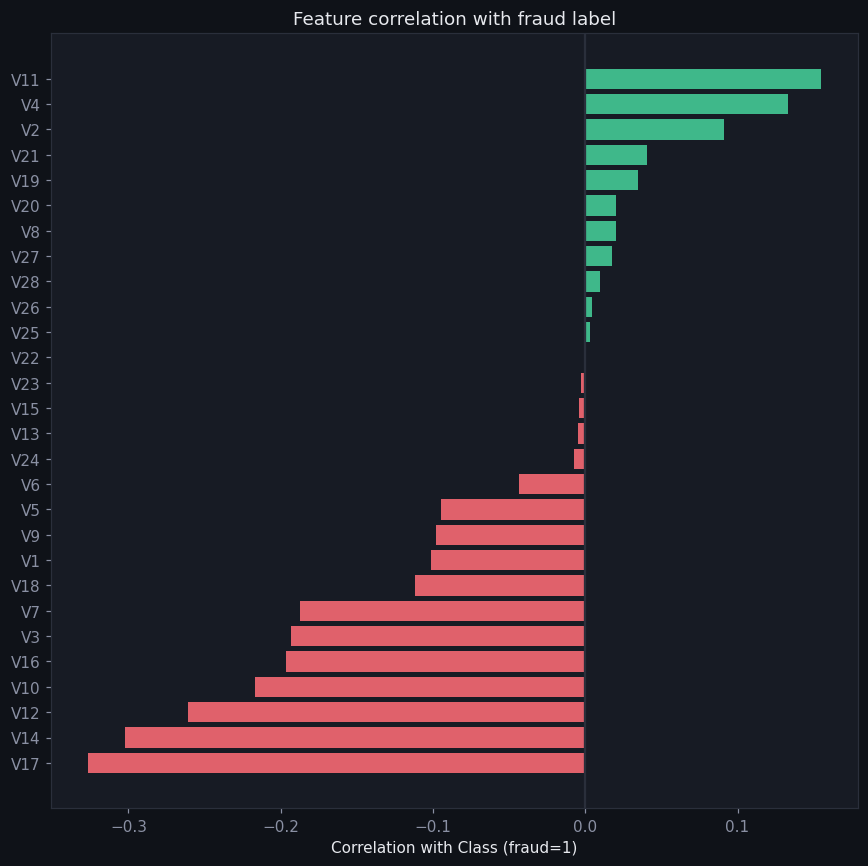

In [7]:
v_features = [f'V{i}' for i in range(1, 29)]
corr_with_class = df[v_features + ['Class']].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#E0616B' if v < 0 else '#3FB88A' for v in corr_with_class.values]
ax.barh(corr_with_class.index, corr_with_class.values, color=colors)
ax.axvline(0, color='#2A2F3B')
ax.set_xlabel('Correlation with Class (fraud=1)')
ax.set_title('Feature correlation with fraud label')
plt.tight_layout()
plt.show()

top5 = corr_with_class.abs().sort_values(ascending=False).head(5)
print("Top 5 most predictive features (by absolute correlation):")
for feat, val in top5.items():
    print(f"  {feat}: {corr_with_class[feat]:+.3f}")

## Summary

- Severe class imbalance (0.17% fraud) — PR-AUC, not accuracy, drives model selection
- ~1,081 duplicate rows removed before splitting to prevent leakage
- Fraud skews toward smaller transaction amounts
- Fraud rate varies meaningfully by hour of day — `hour_of_day` is used as an engineered feature
- A handful of V-features (see chart above) carry most of the separating power

These findings directly shaped the feature engineering and evaluation choices in `src/preprocessing.py` and `src/train_pipeline.py`.